Running Optimization & Generating Plots for: Sphere...


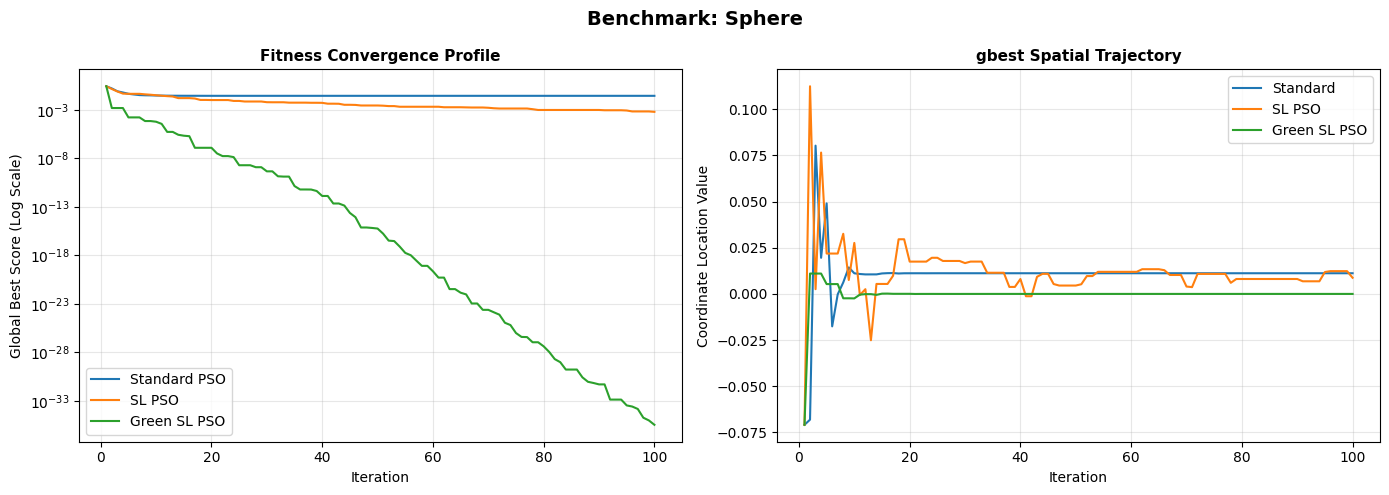

Running Optimization & Generating Plots for: Rosenbrock...


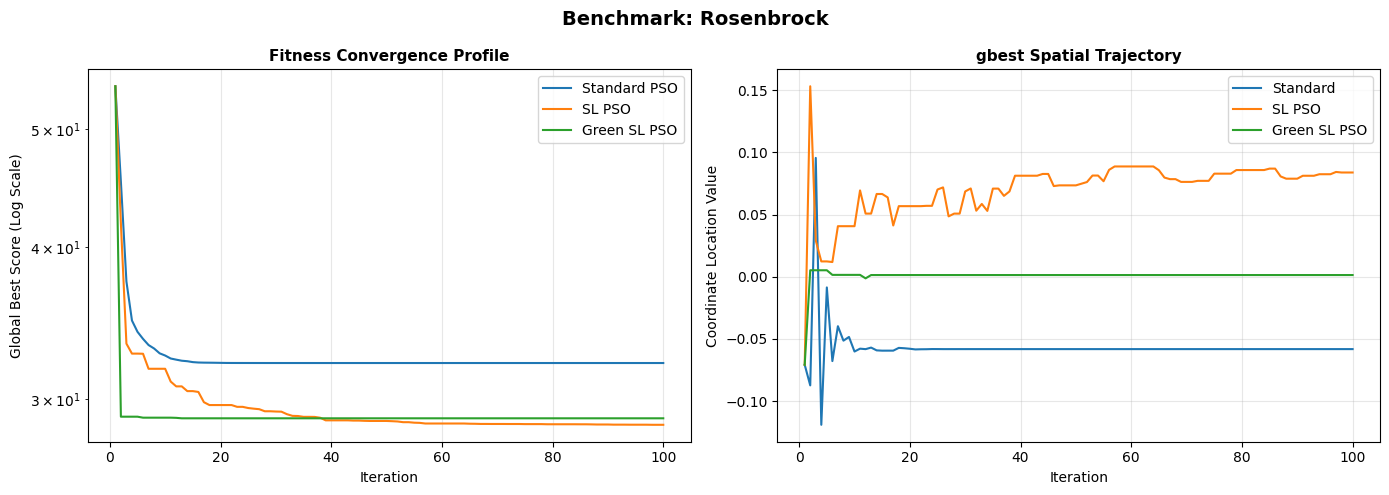

Running Optimization & Generating Plots for: Rastrigin...


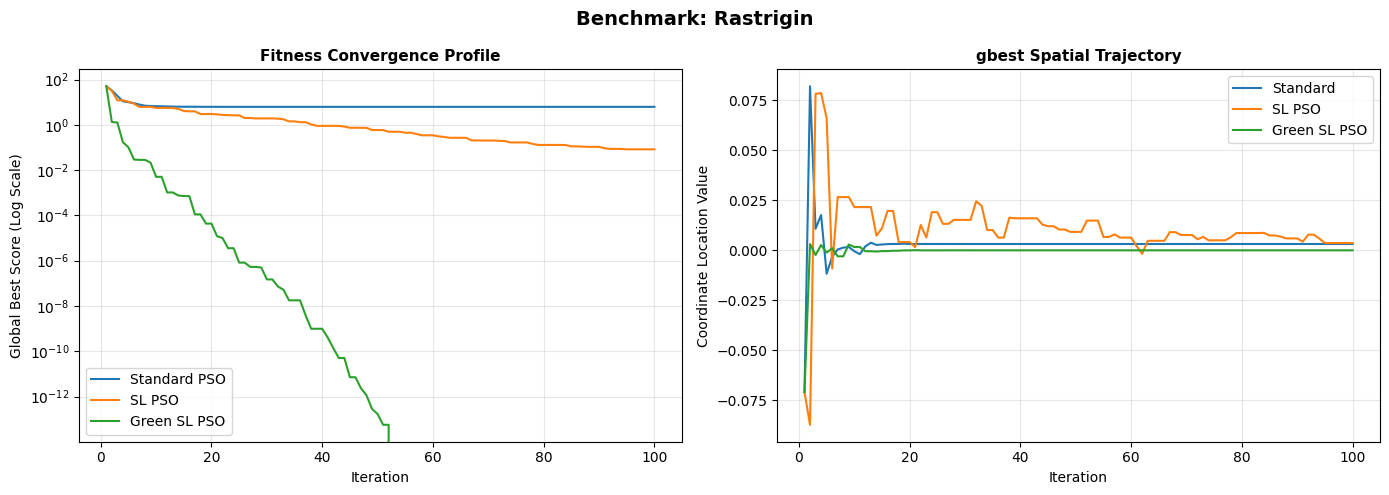

Running Optimization & Generating Plots for: Ackley...


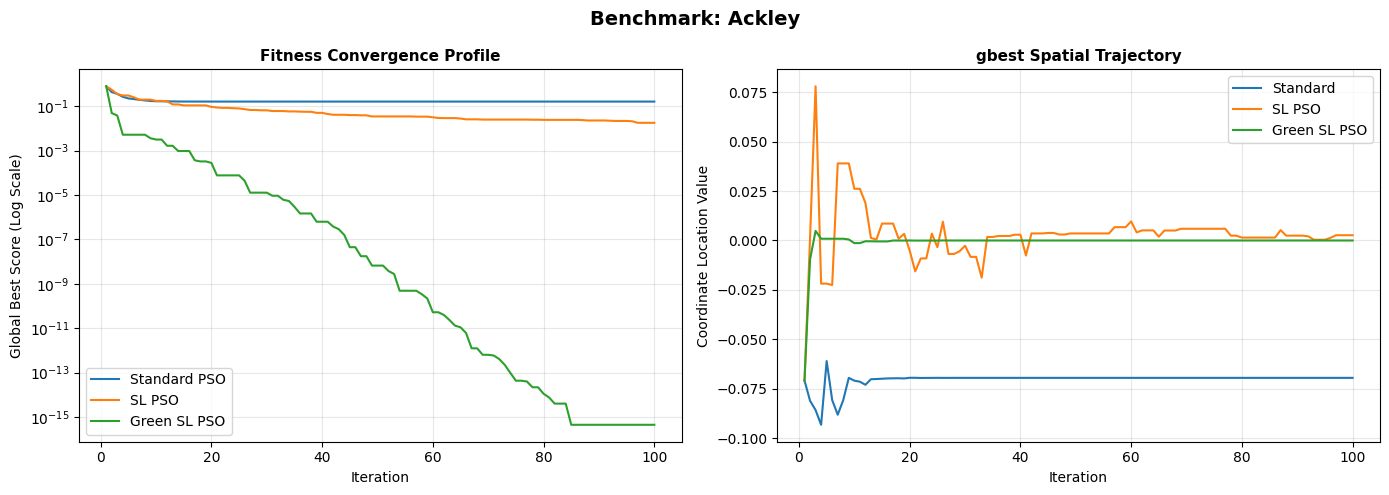

Running Optimization & Generating Plots for: Griewank...


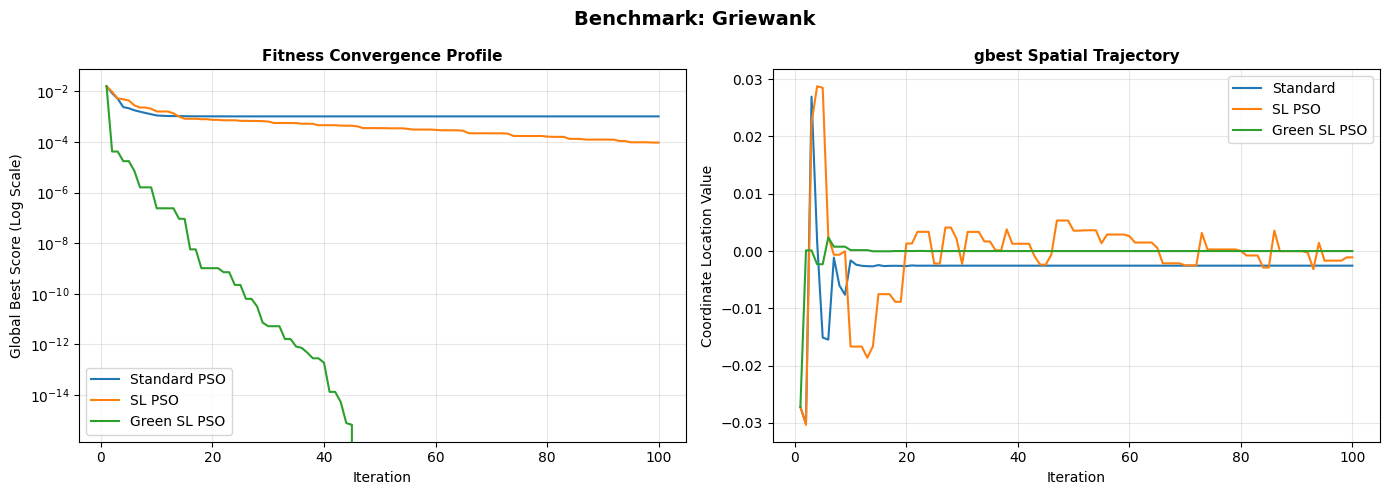

Running Optimization & Generating Plots for: Zakharov...


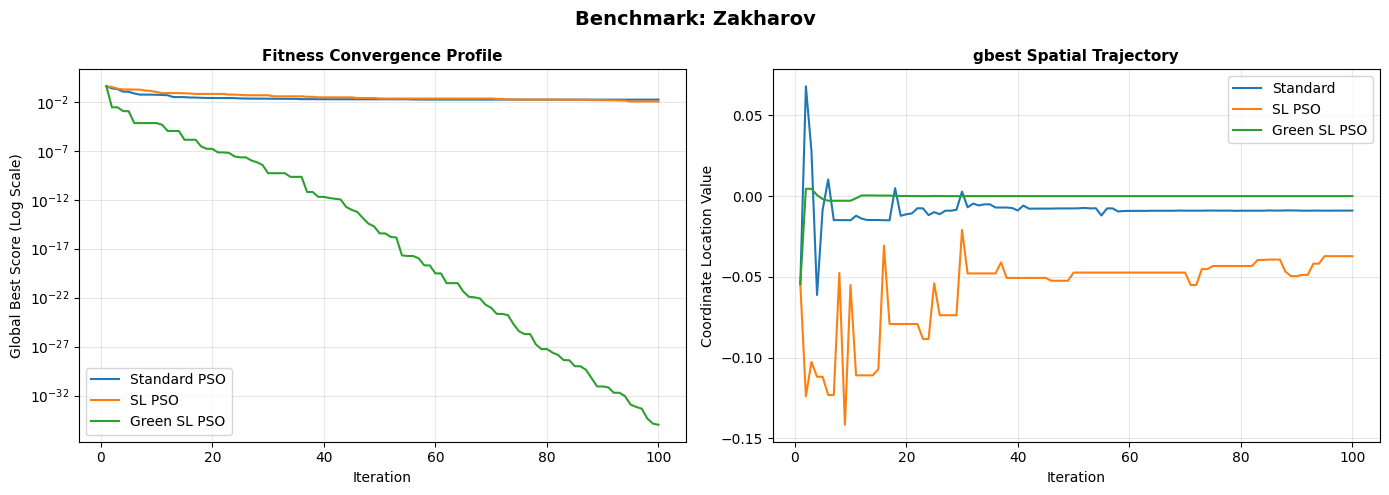

Running Optimization & Generating Plots for: Levy...


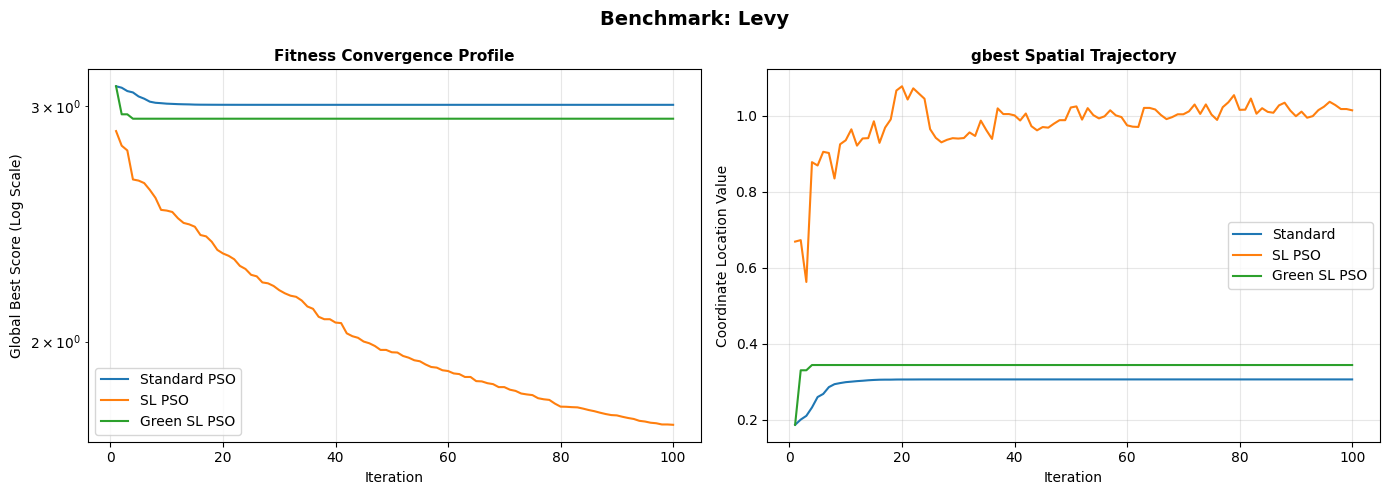

Running Optimization & Generating Plots for: SumDiffPowers...


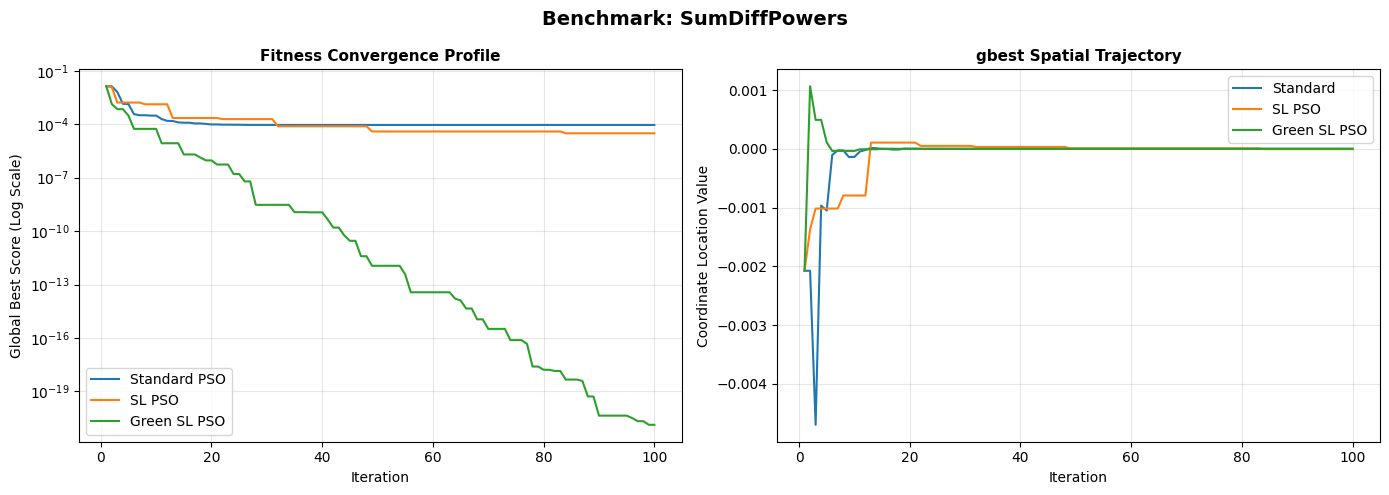

Running Optimization & Generating Plots for: SchafferN2...


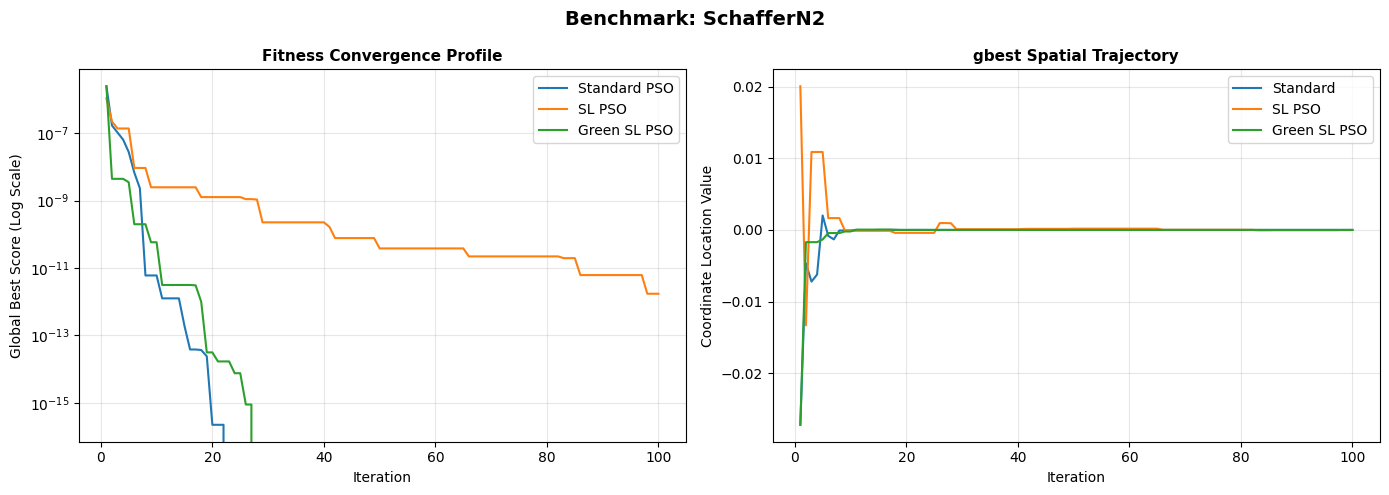

Running Optimization & Generating Plots for: SchafferN4...


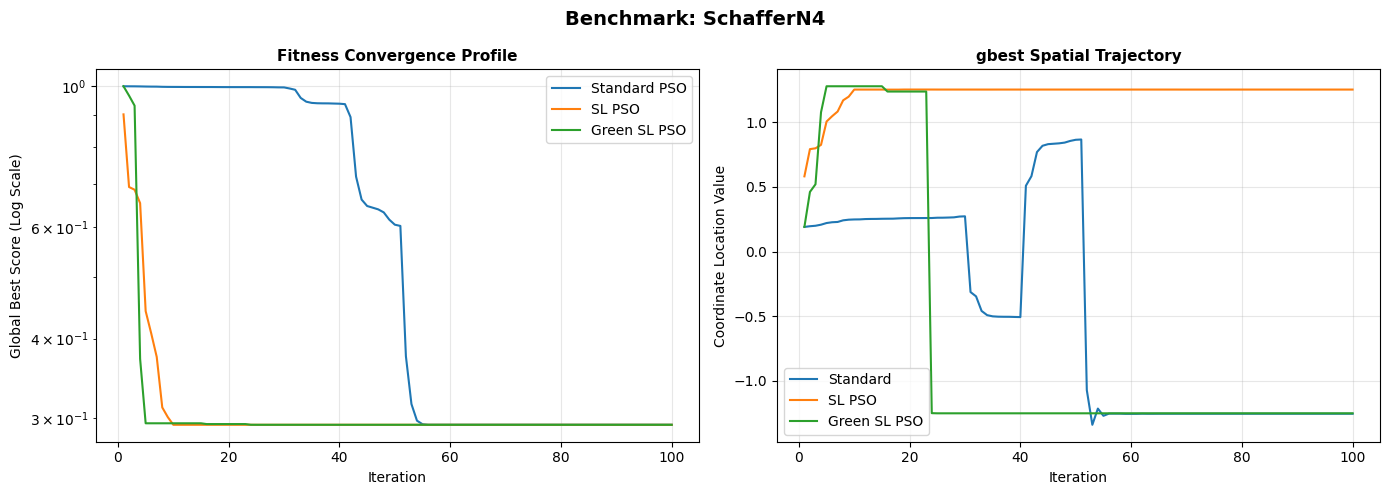

In [4]:
#!/usr/bin/env python3
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.special import j0
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------------------------
# Benchmark functions (10)
# ---------------------------
def sphere(x):
    return float(np.sum(np.asarray(x, dtype=float)**2))

def rosenbrock(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(100.0*(x[1:] - x[:-1]**2)**2 + (x[:-1] - 1.0)**2))

def rastrigin(x):
    x = np.asarray(x, dtype=float)
    return float(10.0*x.size + np.sum(x**2 - 10.0*np.cos(2.0*np.pi*x)))

def ackley(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    s1 = np.sum(x**2)
    s2 = np.sum(np.cos(2*np.pi*x))
    return float(-20.0 * math.exp(-0.2 * math.sqrt(s1 / n)) - math.exp(s2 / n) + 20.0 + math.e)

def griewank(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(x**2) / 4000.0 - np.prod(np.cos(x / np.sqrt(np.arange(1, x.size+1)))) + 1.0)

def zakharov(x):
    x = np.asarray(x, dtype=float)
    s2 = np.sum(0.5 * np.arange(1, x.size+1) * x)
    return float(np.sum(x**2) + s2**2 + s2**4)

def levy(x):
    x = np.asarray(x, dtype=float)
    w = 1.0 + (x - 1.0) / 4.0
    return float(np.sin(np.pi*w[0])**2 + np.sum((w[:-1] - 1.0)**2 * (1.0 + 10.0 * np.sin(np.pi*w[:-1] + 1.0)**2)) + (w[-1] - 1.0)**2 * (1.0 + np.sin(2.0*np.pi*w[-1])**2))

def sum_of_different_powers(x):
    return float(np.sum(np.abs(np.asarray(x, dtype=float))**np.arange(1, x.size+1)))

def schaffer_n2(x):
    x1, x2 = float(x[0]), float(x[1])
    return float(0.5 + ((math.sin(x1**2 - x2**2))**2 - 0.5) / (1.0 + 0.001*(x1**2 + x2**2))**2)

def schaffer_n4(x):
    x1, x2 = float(x[0]), float(x[1])
    return float(0.5 + ((math.cos(math.sin(abs(x1**2 - x2**2)))**2) - 0.5) / (1.0 + 0.001*(x1**2 + x2**2))**2)

benchmark_funcs = [
    ("Sphere", sphere), ("Rosenbrock", rosenbrock), ("Rastrigin", rastrigin),
    ("Ackley", ackley), ("Griewank", griewank), ("Zakharov", zakharov),
    ("Levy", levy), ("SumDiffPowers", sum_of_different_powers),
    ("SchafferN2", schaffer_n2), ("SchafferN4", schaffer_n4)
]

# ---------------------------
# PSO Variations
# ---------------------------
class ParticleStandardVector:
    def __init__(self, x0, c1, c2):
        self.position = np.asarray(x0, dtype=float).copy()
        self.velocity = np.random.randn(*self.position.shape) * 0.05
        self.best_position = self.position.copy()
        self.best_score = float('inf')
        self.c1, self.c2 = c1, c2

class StandardPSOVector:
    def __init__(self, objective_function, initial_positions, max_iter, c1=1.5, c2=0.5, w=0.4):
        self.obj = objective_function
        self.initial_positions = np.asarray(initial_positions, dtype=float)
        self.N, self.dim = self.initial_positions.shape
        self.max_iter = max_iter
        self.c1, self.c2, self.w_base = c1, c2, w
        self.swarm = [ParticleStandardVector(self.initial_positions[i], self.c1, self.c2) for i in range(self.N)]
        self.global_best_position = self.swarm[0].position.copy()
        self.global_best_score = float('inf')

    def optimize(self):
        gbest_score_list = []
        gbest_pos_list = []
        for iteration in range(1, self.max_iter + 1):
            w = self.w_base * math.exp(-float(iteration) / self.max_iter)
            for p in self.swarm:
                score = self.obj(p.position)
                if score < p.best_score:
                    p.best_score = score
                    p.best_position = p.position.copy()
                if score < self.global_best_score:
                    self.global_best_score = score
                    self.global_best_position = p.position.copy()

            gbest_score_list.append(self.global_best_score)
            gbest_pos_list.append(self.global_best_position.copy())
            
            for p in self.swarm:
                cognitive = p.c1 * np.random.rand(self.dim) * (p.best_position - p.position)
                social = p.c2 * np.random.rand(self.dim) * (self.global_best_position - p.position)
                p.velocity = w * p.velocity + cognitive + social
                p.position += p.velocity
        return np.array(gbest_score_list), np.array(gbest_pos_list)

class ParticleCosineVector:
    def __init__(self, x0, c1, c2):
        self.position = np.asarray(x0, dtype=float).copy()
        self.best_position = self.position.copy()
        self.best_score = float('inf')
        self.c1, self.c2 = float(c1), float(c2)

    def update_position(self, iteration, global_best_position, dim):
        phi1, phi2 = self.c1 * np.random.rand(), self.c2 * np.random.rand()
        phi_t = max(phi1 + phi2, 1e-6)
        mu_t = (phi1 * self.best_position + phi2 * global_best_position) / phi_t
        z = math.sqrt(phi_t) * float(iteration)
        u = np.random.randn(dim)
        norm = np.linalg.norm(u)
        u = u / norm if norm > 1e-12 else np.ones(dim) / np.sqrt(dim)
        self.position = mu_t + j0(z) * u

class CosinePSOVector:
    def __init__(self, objective_function, initial_positions, c1, c2, max_iter):
        self.obj = objective_function
        self.initial_positions = np.asarray(initial_positions, dtype=float)
        self.N, self.dim = self.initial_positions.shape
        self.max_iter = max_iter
        self.swarm = [ParticleCosineVector(self.initial_positions[i], c1, c2) for i in range(self.N)]
        self.global_best_position = None
        self.global_best_score = float('inf')
        for p in self.swarm:
            score = self.obj(p.position)
            p.best_score = score
            if score < self.global_best_score:
                self.global_best_score = score
                self.global_best_position = p.position.copy()

    def optimize(self):
        gbest_score_list = []
        gbest_pos_list = []
        for iteration in range(1, self.max_iter + 1):
            for p in self.swarm:
                p.update_position(iteration, self.global_best_position, self.dim)
                score = self.obj(p.position)
                if score < p.best_score:
                    p.best_score = score
                    p.best_position = p.position.copy()
                if score < self.global_best_score:
                    self.global_best_score = score
                    self.global_best_position = p.position.copy()
            gbest_score_list.append(self.global_best_score)
            gbest_pos_list.append(self.global_best_position.copy())
        return np.array(gbest_score_list), np.array(gbest_pos_list)

class ParticleGreenVector:
    def __init__(self, x0, c1, c2, w_const):
        self.x0 = np.asarray(x0, dtype=float).copy()
        self.position = self.x0.copy()
        self.best_position = self.position.copy()
        self.best_score = float('inf')
        self.c1, self.c2, self.w = float(c1), float(c2), float(w_const)
        self.history_F = {0: 1.0, 1: 1.0}
        self.mu_history = [] 

    def _update_characteristic_roots(self, phi_t):
        self.a0 = 1.0
        self.a1 = float(phi_t - 1.0 - self.w)
        self.a2 = float(self.w)
        disc = (self.a1 ** 2) - (4.0 * self.a2)
        if disc < 0:
            real_part = -self.a1 / 2.0
            imag = math.sqrt(max(0.0, -disc)) / 2.0
            self.r_mag = math.hypot(real_part, imag)
            self.omega = math.atan2(imag, real_part) if self.r_mag > 1e-12 else 0.0
            self.root_type = "complex"
        else:
            self.lam1 = (-self.a1 + math.sqrt(disc)) / 2.0
            self.lam2 = (-self.a1 - math.sqrt(disc)) / 2.0
            self.root_type = "real"

    def f0(self, n):
        return (self.r_mag ** n) * math.sin(self.omega * n) if self.root_type == "complex" else float(self.lam1 ** n)

    def f1(self, n):
        return (self.r_mag ** n) * math.cos(self.omega * n) if self.root_type == "complex" else float(self.lam2 ** n)

    def Green_G(self, n, m):
        denom = float(self.f0(m-1) * self.f1(m) - self.f1(m-1) * self.f0(m))
        if abs(denom) < 1e-16: return 0.0
        return float((self.f0(n) * self.f1(m-1) - self.f1(n) * self.f0(m-1)) / denom)

    def compute_F_vector(self, n):
        Pn = np.zeros_like(self.position)
        for m in range(2, n+1):
            rn = (self.mu_history[m] - self.mu_history[m-1]) - self.w * (self.mu_history[m-1] - self.mu_history[m-2])
            Pn += self.Green_G(n, m) * rn
        A = np.array([[self.f0(0), self.f1(0)], [self.f0(1), self.f1(1)]], dtype=float)
        b = np.array([self.history_F[0], self.history_F[1]], dtype=float)
        try:
            C = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            C = np.linalg.lstsq(A, b, rcond=None)[0]
        return ((C[0] * self.f0(n) + C[1] * self.f1(n)) * self.x0) + Pn

    def update_position(self, iteration, global_best_position):
        phi1, phi2 = self.c1 * np.random.uniform(0, 1), self.c2 * np.random.uniform(0, 1)
        phi_t = max(phi1 + phi2, 1e-6)
        self._update_characteristic_roots(phi_t)
        self.mu_history.append((phi1 * self.best_position + phi2 * global_best_position) / phi_t)
        current_idx = len(self.mu_history) - 1
        if current_idx >= 2:
            self.position = self.compute_F_vector(current_idx)

class GreenPSOVector:
    def __init__(self, objective_function, initial_positions, c1, c2, w_const, max_iter):
        self.obj = objective_function
        self.initial_positions = np.asarray(initial_positions, dtype=float)
        self.N, self.dim = self.initial_positions.shape
        self.max_iter = max_iter
        self.swarm = [ParticleGreenVector(self.initial_positions[i], c1, c2, w_const) for i in range(self.N)]
        self.global_best_position = None
        self.global_best_score = float('inf')
        for p in self.swarm:
            score = self.obj(p.position)
            p.best_score = score
            if score < self.global_best_score:
                self.global_best_score = score
                self.global_best_position = p.position.copy()
        for p in self.swarm:
            r1, r2 = np.random.uniform(0, 1), np.random.uniform(0, 1)
            phi_t = max((c1 * r1) + (c2 * r2), 1e-6)
            p.mu_history.append(((c1 * r1) * p.best_position + (c2 * r2) * self.global_best_position) / phi_t)

    def optimize(self):
        gbest_score_list = []
        gbest_pos_list = []
        for iteration in range(1, self.max_iter + 1):
            for p in self.swarm:
                p.update_position(iteration, self.global_best_position)
                score = self.obj(p.position)
                if score < p.best_score:
                    p.best_score = score
                    p.best_position = p.position.copy()
                if score < self.global_best_score:
                    self.global_best_score = score
                    self.global_best_position = p.position.copy()
            gbest_score_list.append(self.global_best_score)
            gbest_pos_list.append(self.global_best_position.copy())
        return np.array(gbest_score_list), np.array(gbest_pos_list)

# ---------------------------
# Execution Runtime
# ---------------------------
if __name__ == "__main__":
    np.random.seed(5)
    num_particles, dim, max_iter = 50, 30, 100
    initial_positions = np.random.uniform(-0.2, 0.2, size=(num_particles, dim))
    iterations = np.arange(1, max_iter + 1)

    for name, func in benchmark_funcs:
        print(f"Running Optimization & Generating Plots for: {name}...")
        
        std = StandardPSOVector(func, initial_positions, max_iter=max_iter)
        cos = CosinePSOVector(func, initial_positions, c1=1.5, c2=0.5, max_iter=max_iter)
        green = GreenPSOVector(func, initial_positions, 1.5, 0.5, 0.4, max_iter=max_iter)

        std_scores, std_pos = std.optimize()
        cos_scores, cos_pos = cos.optimize()
        green_scores, green_pos = green.optimize()

        # Dual-Panel Figure Layout
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot 1: Convergence profile (Fitness Value)
        ax1.plot(iterations, std_scores, label="Standard PSO", color="C0", linewidth=1.5)
        ax1.plot(iterations, cos_scores, label="SL PSO", color="C1", linewidth=1.5)
        ax1.plot(iterations, green_scores, label="Green SL PSO", color="C2", linewidth=1.5)
        ax1.set_yscale('log')
        ax1.set_title("Fitness Convergence Profile", fontsize=11, fontweight='bold')
        ax1.set_xlabel("Iteration")
        ax1.set_ylabel("Global Best Score (Log Scale)")
        ax1.grid(True, alpha=0.3)
        ax1.legend()

        # Plot 2: Trajectory mapping of gbest position coords 
        ax2.plot(iterations, std_pos[:, 0], label="Standard", color="C0", linewidth=1.5)
        ax2.plot(iterations, cos_pos[:, 0], label="SL PSO", color="C1", linewidth=1.5)
        ax2.plot(iterations, green_pos[:, 0], label="Green SL PSO", color="C2", linewidth=1.5)
        
        ax2.set_title("gbest Spatial Trajectory", fontsize=11, fontweight='bold')
        ax2.set_xlabel("Iteration")
        ax2.set_ylabel("Coordinate Location Value")
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc="best")

        plt.suptitle(f"Benchmark: {name}", fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()

# Range Specified


Optimizing: Rosenbrock | Bounds: [-5, 10] over 30 independent runs...


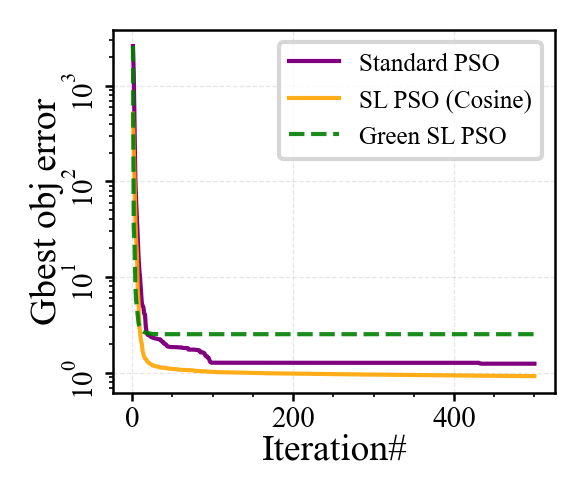

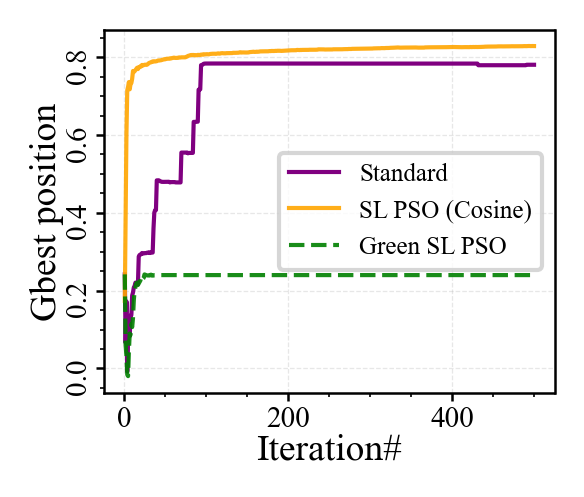

In [ ]:
#!/usr/bin/env python3
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.special import j0
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------------------------
# Benchmark functions (10)
# ---------------------------
def sphere(x):
    return float(np.sum(np.asarray(x, dtype=float)**2))

def rosenbrock(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(100.0*(x[1:] - x[:-1]**2)**2 + (x[:-1] - 1.0)**2))

def r_rastrigin(x):
    x = np.asarray(x, dtype=float)
    return float(10.0*x.size + np.sum(x**2 - 10.0*np.cos(2.0*np.pi*x)))

def ackley(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    s1 = np.sum(x**2)
    s2 = np.sum(np.cos(2*np.pi*x))
    return float(-20.0 * math.exp(-0.2 * math.sqrt(s1 / n)) - math.exp(s2 / n) + 20.0 + math.e)

def griewank(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(x**2) / 4000.0 - np.prod(np.cos(x / np.sqrt(np.arange(1, x.size+1)))) + 1.0)

def zakharov(x):
    x = np.asarray(x, dtype=float)
    s2 = np.sum(0.5 * np.arange(1, x.size+1) * x)
    return float(np.sum(x**2) + s2**2 + s2**4)

def levy(x):
    x = np.asarray(x, dtype=float)
    w = 1.0 + (x - 1.0) / 4.0
    return float(np.sin(np.pi*w[0])**2 + np.sum((w[:-1] - 1.0)**2 * (1.0 + 10.0 * np.sin(np.pi*w[:-1] + 1.0)**2)) + (w[-1] - 1.0)**2 * (1.0 + np.sin(2.0*np.pi*w[-1])**2))

def sum_of_different_powers(x):
    return float(np.sum(np.abs(np.asarray(x, dtype=float))**np.arange(1, x.size+1)))

def schaffer_n2(x):
    x1, x2 = float(x[0]), float(x[1])
    return float(0.5 + ((math.sin(x1**2 - x2**2))**2 - 0.5) / (1.0 + 0.001*(x1**2 + x2**2))**2)

def schaffer_n4(x):
    x1, x2 = float(x[0]), float(x[1])
    return float(0.5 + ((math.cos(math.sin(abs(x1**2 - x2**2)))**2) - 0.5) / (1.0 + 0.001*(x1**2 + x2**2))**2)

benchmark_funcs = [
    (sphere, -5.12, 5.12),
    (r_rastrigin, -5.12, 5.12),
    (ackley, -32.768, 32.768),
    (griewank, -600, 600),
    (zakharov, -5, 10),
    (sum_of_different_powers, -1, 1),
    (rosenbrock, -5, 10),
    (schaffer_n2, -100, 100),
    (schaffer_n4, -100, 100),
    (levy, -10, 10)
]

# ---------------------------
# PSO Variations
# ---------------------------
class ParticleStandardVector:
    def __init__(self, x0, c1, c2):
        self.position = np.asarray(x0, dtype=float).copy()
        self.velocity = np.random.randn(*self.position.shape) * 0.05
        self.best_position = self.position.copy()
        self.best_score = float('inf')
        self.c1, self.c2 = c1, c2

class StandardPSOVector:
    def __init__(self, objective_function, initial_positions, low_b, up_b, max_iter, c1=1.5, c2=0.5, w=0.4):
        self.obj = objective_function
        self.initial_positions = np.asarray(initial_positions, dtype=float)
        self.low_b = low_b
        self.up_b = up_b
        self.N, self.dim = self.initial_positions.shape
        self.max_iter = max_iter
        self.c1, self.c2, self.w_base = c1, c2, w
        self.swarm = [ParticleStandardVector(self.initial_positions[i], self.c1, self.c2) for i in range(self.N)]
        self.global_best_position = self.swarm[0].position.copy()
        self.global_best_score = float('inf')

    def optimize(self):
        gbest_score_list = []
        gbest_pos_list = []
        for iteration in range(1, self.max_iter + 1):
            w = self.w_base * math.exp(-float(iteration) / self.max_iter)
            for p in self.swarm:
                score = self.obj(p.position)
                if score < p.best_score:
                    p.best_score = score
                    p.best_position = p.position.copy()
                if score < self.global_best_score:
                    self.global_best_score = score
                    self.global_best_position = p.position.copy()

            gbest_score_list.append(self.global_best_score)
            gbest_pos_list.append(self.global_best_position.copy())
            
            for p in self.swarm:
                cognitive = p.c1 * np.random.rand(self.dim) * (p.best_position - p.position)
                social = p.c2 * np.random.rand(self.dim) * (self.global_best_position - p.position)
                p.velocity = w * p.velocity + cognitive + social
                p.position += p.velocity
                p.position = np.clip(p.position, self.low_b, self.up_b)
        return np.array(gbest_score_list), np.array(gbest_pos_list)

class ParticleCosineVector:
    def __init__(self, x0, c1, c2):
        self.position = np.asarray(x0, dtype=float).copy()
        self.best_position = self.position.copy()
        self.best_score = float('inf')
        self.c1, self.c2 = float(c1), float(c2)

    def update_position(self, iteration, global_best_position, dim, low_b, up_b):
        phi1, phi2 = self.c1 * np.random.rand(), self.c2 * np.random.rand()
        phi_t = max(phi1 + phi2, 1e-6)
        mu_t = (phi1 * self.best_position + phi2 * global_best_position) / phi_t
        z = math.sqrt(phi_t) * float(iteration)
        u = np.random.randn(dim)
        norm = np.linalg.norm(u)
        u = u / norm if norm > 1e-12 else np.ones(dim) / np.sqrt(dim)
        self.position = mu_t + j0(z) * u
        self.position = np.clip(self.position, low_b, up_b)

class CosinePSOVector:
    def __init__(self, objective_function, initial_positions, low_b, up_b, c1, c2, max_iter):
        self.obj = objective_function
        self.initial_positions = np.asarray(initial_positions, dtype=float)
        self.low_b = low_b
        self.up_b = up_b
        self.N, self.dim = self.initial_positions.shape
        self.max_iter = max_iter
        self.swarm = [ParticleCosineVector(self.initial_positions[i], c1, c2) for i in range(self.N)]
        self.global_best_position = None
        self.global_best_score = float('inf')
        for p in self.swarm:
            score = self.obj(p.position)
            p.best_score = score
            if score < self.global_best_score:
                self.global_best_score = score
                self.global_best_position = p.position.copy()

    def optimize(self):
        gbest_score_list = []
        gbest_pos_list = []
        for iteration in range(1, self.max_iter + 1):
            for p in self.swarm:
                p.update_position(iteration, self.global_best_position, self.dim, self.low_b, self.up_b)
                score = self.obj(p.position)
                if score < p.best_score:
                    p.best_score = score
                    p.best_position = p.position.copy()
                if score < self.global_best_score:
                    self.global_best_score = score
                    self.global_best_position = p.position.copy()
            gbest_score_list.append(self.global_best_score)
            gbest_pos_list.append(self.global_best_position.copy())
        return np.array(gbest_score_list), np.array(gbest_pos_list)

class ParticleGreenVector:
    def __init__(self, x0, c1, c2, w_const):
        self.x0 = np.asarray(x0, dtype=float).copy()
        self.position = self.x0.copy()
        self.best_position = self.position.copy()
        self.best_score = float('inf')
        self.c1, self.c2, self.w = float(c1), float(c2), float(w_const)
        self.history_F = {0: 1.0, 1: 1.0}
        self.mu_history = [] 

    def _update_characteristic_roots(self, phi_t):
        self.a0 = 1.0
        self.a1 = float(phi_t - 1.0 - self.w)
        self.a2 = float(self.w)
        disc = (self.a1 ** 2) - (4.0 * self.a2)
        if disc < 0:
            real_part = -self.a1 / 2.0
            imag = math.sqrt(max(0.0, -disc)) / 2.0
            self.r_mag = math.hypot(real_part, imag)
            self.omega = math.atan2(imag, real_part) if self.r_mag > 1e-12 else 0.0
            self.root_type = "complex"
        else:
            self.lam1 = (-self.a1 + math.sqrt(disc)) / 2.0
            self.lam2 = (-self.a1 - math.sqrt(disc)) / 2.0
            self.root_type = "real"

    def f0(self, n):
        return (self.r_mag ** n) * math.sin(self.omega * n) if self.root_type == "complex" else float(self.lam1 ** n)

    def f1(self, n):
        return (self.r_mag ** n) * math.cos(self.omega * n) if self.root_type == "complex" else float(self.lam2 ** n)

    def Green_G(self, n, m):
        denom = float(self.f0(m-1) * self.f1(m) - self.f1(m-1) * self.f0(m))
        if abs(denom) < 1e-16: return 0.0
        return float((self.f0(n) * self.f1(m-1) - self.f1(n) * self.f0(m-1)) / denom)

    def compute_F_vector(self, n):
        Pn = np.zeros_like(self.position)
        for m in range(2, n+1):
            rn = (self.mu_history[m] - self.mu_history[m-1]) - self.w * (self.mu_history[m-1] - self.mu_history[m-2])
            Pn += self.Green_G(n, m) * rn
        A = np.array([[self.f0(0), self.f1(0)], [self.f0(1), self.f1(1)]], dtype=float)
        b = np.array([self.history_F[0], self.history_F[1]], dtype=float)
        try:
            C = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            C = np.linalg.lstsq(A, b, rcond=None)[0]
        return ((C[0] * self.f0(n) + C[1] * self.f1(n)) * self.x0) + Pn

    def update_position(self, iteration, global_best_position, low_b, up_b):
        phi1, phi2 = self.c1 * np.random.uniform(0, 1), self.c2 * np.random.uniform(0, 1)
        phi_t = max(phi1 + phi2, 1e-6)
        self._update_characteristic_roots(phi_t)
        self.mu_history.append((phi1 * self.best_position + phi2 * global_best_position) / phi_t)
        current_idx = len(self.mu_history) - 1
        if current_idx >= 2:
            self.position = self.compute_F_vector(current_idx)
        self.position = np.clip(self.position, low_b, up_b)

class GreenPSOVector:
    def __init__(self, objective_function, initial_positions, low_b, up_b, c1, c2, w_const, max_iter):
        self.obj = objective_function
        self.initial_positions = np.asarray(initial_positions, dtype=float)
        self.low_b = low_b
        self.up_b = up_b
        self.N, self.dim = self.initial_positions.shape
        self.max_iter = max_iter
        self.swarm = [ParticleGreenVector(self.initial_positions[i], c1, c2, w_const) for i in range(self.N)]
        self.global_best_position = None
        self.global_best_score = float('inf')
        for p in self.swarm:
            score = self.obj(p.position)
            p.best_score = score
            if score < self.global_best_score:
                self.global_best_score = score
                self.global_best_position = p.position.copy()
        for p in self.swarm:
            r1, r2 = np.random.uniform(0, 1), np.random.uniform(0, 1)
            phi_t = max((c1 * r1) + (c2 * r2), 1e-6)
            p.mu_history.append(((c1 * r1) * p.best_position + (c2 * r2) * self.global_best_position) / phi_t)

    def optimize(self):
        gbest_score_list = []
        gbest_pos_list = []
        for iteration in range(1, self.max_iter + 1):
            for p in self.swarm:
                p.update_position(iteration, self.global_best_position, self.low_b, self.up_b)
                score = self.obj(p.position)
                if score < p.best_score:
                    p.best_score = score
                    p.best_position = p.position.copy()
                if score < self.global_best_score:
                    self.global_best_score = score
                    self.global_best_position = p.position.copy()
            gbest_score_list.append(self.global_best_score)
            gbest_pos_list.append(self.global_best_position.copy())
        return np.array(gbest_score_list), np.array(gbest_pos_list)

# ---------------------------
# Execution Runtime
# ---------------------------

# ---------------------------
if __name__ == "__main__":
    # ==========================================================
    # IEEE Transactions Compact 4-Grid Template
    # ==========================================================
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    
    # ----------------------------------------------------------
    # Font settings
    # ----------------------------------------------------------
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Times New Roman']

    # ----------------------------------------------------------
    # Compact subplot size for 4-grid in double column
    # ----------------------------------------------------------
    mpl.rcParams['figure.figsize'] = (1.79, 1.5)

    # ----------------------------------------------------------
    # Resolution
    # ----------------------------------------------------------
    mpl.rcParams['figure.dpi'] = 300
    mpl.rcParams['savefig.dpi'] = 600

    # ----------------------------------------------------------
    # Axes styling
    # ----------------------------------------------------------
    mpl.rcParams['axes.labelsize'] = 9
    mpl.rcParams['axes.titlesize'] = 10
    mpl.rcParams['axes.linewidth'] = 0.6
    mpl.rcParams['axes.labelpad'] = 1

    # ----------------------------------------------------------
    # Tick label styling
    # ----------------------------------------------------------
    mpl.rcParams['xtick.labelsize'] = 7
    mpl.rcParams['ytick.labelsize'] = 7
    mpl.rcParams['xtick.major.pad'] = 1
    mpl.rcParams['ytick.major.pad'] = 1

    # ----------------------------------------------------------
    # Major ticks
    # ----------------------------------------------------------
    mpl.rcParams['xtick.major.width'] = 0.6
    mpl.rcParams['ytick.major.width'] = 0.6
    mpl.rcParams['xtick.major.size'] = 2
    mpl.rcParams['ytick.major.size'] = 2

    # ----------------------------------------------------------
    # Minor ticks
    # ----------------------------------------------------------
    mpl.rcParams['xtick.minor.visible'] = True
    mpl.rcParams['ytick.minor.visible'] = True
    mpl.rcParams['xtick.minor.width'] = 0.4
    mpl.rcParams['ytick.minor.width'] = 0.4
    mpl.rcParams['xtick.minor.size'] = 1
    mpl.rcParams['ytick.minor.size'] = 1

    # ----------------------------------------------------------
    # Grid settings
    # ----------------------------------------------------------
    mpl.rcParams['axes.grid'] = True
    mpl.rcParams['grid.linewidth'] = 0.3
    mpl.rcParams['grid.alpha'] = 0.4
    mpl.rcParams['grid.linestyle'] = '--'

    # ----------------------------------------------------------
    # Legend
    # ----------------------------------------------------------
    mpl.rcParams['legend.fontsize'] = 6
    mpl.rcParams['legend.frameon'] = True

    # ----------------------------------------------------------
    # Line and marker settings
    # ----------------------------------------------------------
    mpl.rcParams['lines.linewidth'] = 0.9
    mpl.rcParams['lines.markersize'] = 3

    # ----------------------------------------------------------
    # Export settings
    # ----------------------------------------------------------
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42

    # Configuration for the statistical run
    num_particles = 50
    max_iter = 500
    num_runs = 30
    iterations = np.arange(1, max_iter + 1)

    for func, low_b, up_b in benchmark_funcs:
        func_name = func.__name__.capitalize()
        if func_name == "R_rastrigin":
            func_name = "Rastrigin"
            
        dim = 4 if func_name in ["Schaffer_n2", "Schaffer_n4"] else 4
        print(f"Optimizing: {func_name} | Bounds: [{low_b}, {up_b}] over {num_runs} independent runs...")
        
        # Initialize containers to store optimization histories across runs
        # Shape: (num_runs, max_iter) for scores, (num_runs, max_iter, dim) for positions
        all_std_scores = np.zeros((num_runs, max_iter))
        all_cos_scores = np.zeros((num_runs, max_iter))
        all_green_scores = np.zeros((num_runs, max_iter))
        
        all_std_pos = np.zeros((num_runs, max_iter, dim))
        all_cos_pos = np.zeros((num_runs, max_iter, dim))
        all_green_pos = np.zeros((num_runs, max_iter, dim))
        
        # Execute the independent runs
        for run in range(num_runs):
            # Seed uniquely per run, but keep overall script executions reproducible
            np.random.seed(run + 42)
            
            initial_positions = np.random.uniform(low_b, up_b, size=(num_particles, dim))
            
            std = StandardPSOVector(func, initial_positions, low_b, up_b, max_iter=max_iter)
            cos = CosinePSOVector(func, initial_positions, low_b, up_b, c1=1.5, c2=0.5, max_iter=max_iter)
            green = GreenPSOVector(func, initial_positions, low_b, up_b, 1.5, 0.5, 0.4, max_iter=max_iter)

            std_scores, std_pos = std.optimize()
            cos_scores, cos_pos = cos.optimize()
            green_scores, green_pos = green.optimize()
            
            all_std_scores[run, :] = std_scores
            all_cos_scores[run, :] = cos_scores
            all_green_scores[run, :] = green_scores
            
            all_std_pos[run, :, :] = std_pos
            all_cos_pos[run, :, :] = cos_pos
            all_green_pos[run, :, :] = green_pos

        # Compute the mean over the 30 independent runs (axis=0)
        avg_std_scores = np.mean(all_std_scores, axis=0)
        avg_cos_scores = np.mean(all_cos_scores, axis=0)
        avg_green_scores = np.mean(all_green_scores, axis=0)
        
        # Taking the mean position of the first dimension (index 0) across all runs
        avg_std_pos_dim0 = np.mean(all_std_pos[:, :, 0], axis=0)
        avg_cos_pos_dim0 = np.mean(all_cos_pos[:, :, 0], axis=0)
        avg_green_pos_dim0 = np.mean(all_green_pos[:, :, 0], axis=0)

        # ----------------------------------------------------------
        # Plot 1: Mean gbest objective error
        # ----------------------------------------------------------
        plt.figure(figsize=(1.79, 1.5))
        plt.plot(iterations, avg_std_scores, label="Standard PSO", color="purple", alpha=1, linewidth=1)
        plt.plot(iterations, avg_cos_scores, label="SL PSO (Cosine)", color="orange", alpha=0.9, linewidth=1)
        plt.plot(iterations, avg_green_scores, label="Green SL PSO", color="green", linestyle='--', alpha=0.9, linewidth=1)
        
        plt.yscale('log')
        plt.yticks(rotation=90)
        plt.xlabel("Iteration#", labelpad=0.2)
        plt.ylabel("Gbest obj error", labelpad=0.2)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout(pad=0.15)
        plt.savefig(f"{func_name}_GbestObjectiveW1.pdf", dpi=600, bbox_inches='tight')
        plt.show()
        
        # ----------------------------------------------------------
        # Plot 2: Mean gbest position (Dimension 0)
        # ----------------------------------------------------------
        plt.figure(figsize=(1.79, 1.5))
        plt.plot(iterations, avg_std_pos_dim0, label="Standard", color="purple", alpha=1, linewidth=1)
        plt.plot(iterations, avg_cos_pos_dim0, label="SL PSO (Cosine)", color="orange", alpha=0.9, linewidth=1)
        plt.plot(iterations, avg_green_pos_dim0, label="Green SL PSO", color="green", linestyle='--', alpha=0.9, linewidth=1)
        
        plt.yticks(rotation=90)
        plt.xlabel("Iteration#", labelpad=0.2)
        plt.ylabel("Gbest position", labelpad=0.2)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout(pad=0.15)
        plt.savefig(f"{func_name}_GbestPositionW1.pdf", dpi=600, bbox_inches='tight')
        plt.show()

Evaluating: Rosenbrock | Dimensions: 3 | Averaging over 30 runs...


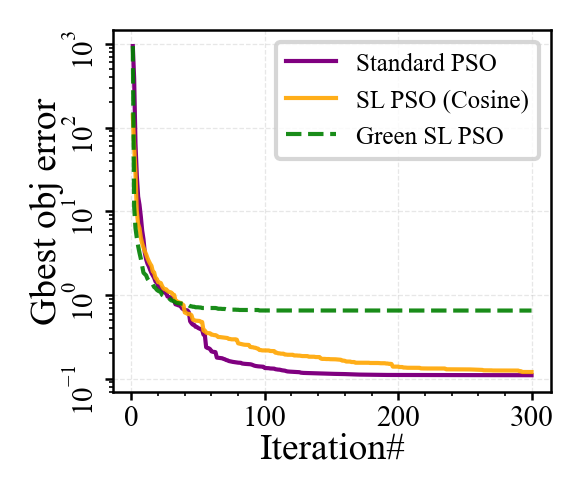

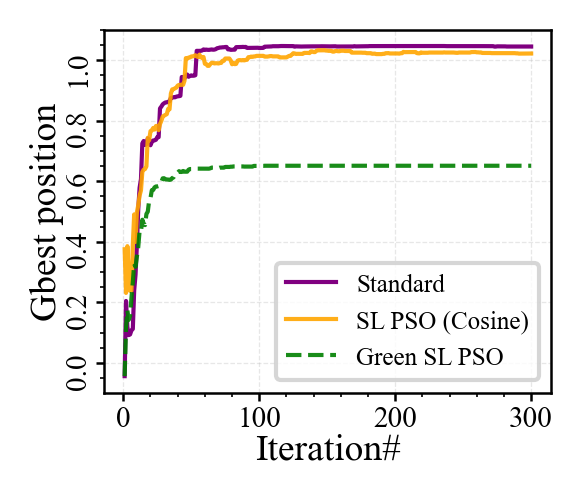

Evaluating: Levy | Dimensions: 3 | Averaging over 30 runs...


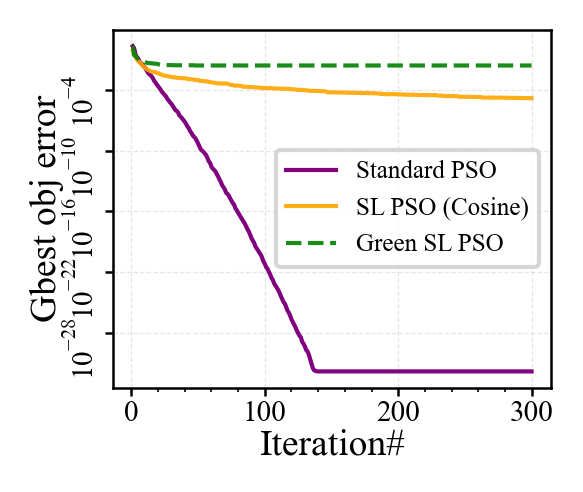

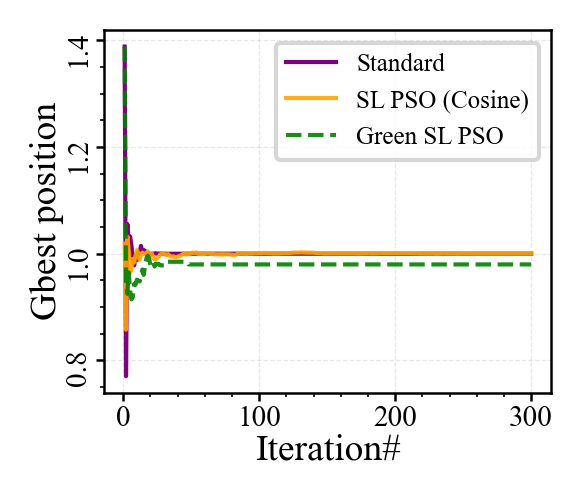

In [16]:
#!/usr/bin/env python3
import numpy as np
import math
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------------------------
# Benchmark functions (10)
# ---------------------------
def sphere(x):
    return float(np.sum(np.asarray(x, dtype=float)**2))

def rosenbrock(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(100.0*(x[1:] - x[:-1]**2)**2 + (x[:-1] - 1.0)**2))

def r_rastrigin(x):
    x = np.asarray(x, dtype=float)
    return float(10.0*x.size + np.sum(x**2 - 10.0*np.cos(2.0*np.pi*x)))

def ackley(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    s1 = np.sum(x**2)
    s2 = np.sum(np.cos(2*np.pi*x))
    return float(-20.0 * math.exp(-0.2 * math.sqrt(s1 / n)) - math.exp(s2 / n) + 20.0 + math.e)

def griewank(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(x**2) / 4000.0 - np.prod(np.cos(x / np.sqrt(np.arange(1, x.size+1)))) + 1.0)

def zakharov(x):
    x = np.asarray(x, dtype=float)
    s2 = np.sum(0.5 * np.arange(1, x.size+1) * x)
    return float(np.sum(x**2) + s2**2 + s2**4)

def levy(x):
    x = np.asarray(x, dtype=float)
    w = 1.0 + (x - 1.0) / 4.0
    return float(np.sin(np.pi*w[0])**2 + np.sum((w[:-1] - 1.0)**2 * (1.0 + 10.0 * np.sin(np.pi*w[:-1] + 1.0)**2)) + (w[-1] - 1.0)**2 * (1.0 + np.sin(2.0*np.pi*w[-1])**2))

def sum_of_different_powers(x):
    return float(np.sum(np.abs(np.asarray(x, dtype=float))**np.arange(1, x.size+1)))

def schaffer_n2(x):
    x1, x2 = float(x[0]), float(x[1])
    return float(0.5 + ((math.sin(x1**2 - x2**2))**2 - 0.5) / (1.0 + 0.001*(x1**2 + x2**2))**2)

def schaffer_n4(x):
    x1, x2 = float(x[0]), float(x[1])
    return float(0.5 + ((math.cos(math.sin(abs(x1**2 - x2**2)))**2) - 0.5) / (1.0 + 0.001*(x1**2 + x2**2))**2)

benchmark_funcs = [
    # (sphere, -5.12, 5.12),
    # (r_rastrigin, -5.12, 5.12),
    # (ackley, -32.768, 32.768),
    # (griewank, -600, 600),
    # (zakharov, -5, 10),
    # (sum_of_different_powers, -1, 1),
    (rosenbrock, -5, 10),
    # (schaffer_n2, -100, 100),
    # (schaffer_n4, -100, 100),
    (levy, -10, 10)
]

# ---------------------------
# PSO Variations
# ---------------------------
class ParticleStandardVector:
    def __init__(self, x0, c1, c2):
        self.position = np.asarray(x0, dtype=float).copy()
        self.velocity = np.random.randn(*self.position.shape) * 0.05
        self.best_position = self.position.copy()
        self.best_score = float('inf')
        self.c1, self.c2 = c1, c2

class StandardPSOVector:
    def __init__(self, objective_function, initial_positions, low_b, up_b, max_iter, c1=1.5, c2=0.5, w=0.7):
        self.obj = objective_function
        self.initial_positions = np.asarray(initial_positions, dtype=float)
        self.low_b = low_b
        self.up_b = up_b
        self.N, self.dim = self.initial_positions.shape
        self.max_iter = max_iter
        self.c1, self.c2, self.w_base = c1, c2, w
        self.swarm = [ParticleStandardVector(self.initial_positions[i], self.c1, self.c2) for i in range(self.N)]
        self.global_best_position = self.swarm[0].position.copy()
        self.global_best_score = float('inf')

    def optimize(self):
        gbest_score_list = []
        gbest_pos_list = []
        for iteration in range(1, self.max_iter + 1):
            w = self.w_base * math.exp(-float(iteration) / self.max_iter)
            for p in self.swarm:
                score = self.obj(p.position)
                if score < p.best_score:
                    p.best_score = score
                    p.best_position = p.position.copy()
                if score < self.global_best_score:
                    self.global_best_score = score
                    self.global_best_position = p.position.copy()

            gbest_score_list.append(self.global_best_score)
            gbest_pos_list.append(self.global_best_position.copy())
            
            for p in self.swarm:
                cognitive = p.c1 * np.random.rand(self.dim) * (p.best_position - p.position)
                social = p.c2 * np.random.rand(self.dim) * (self.global_best_position - p.position)
                p.velocity = w * p.velocity + cognitive + social
                p.position += p.velocity
                p.position = np.clip(p.position, self.low_b, self.up_b)
        return np.array(gbest_score_list), np.array(gbest_pos_list)

class ParticleCosineVector:
    def __init__(self, x0, c1, c2):
        self.position = np.asarray(x0, dtype=float).copy()
        self.best_position = self.position.copy()
        self.best_score = float('inf')
        self.c1, self.c2 = float(c1), float(c2)

    def update_position(self, iteration, global_best_position, dim, low_b, up_b):
        phi1, phi2 = self.c1 * np.random.rand(), self.c2 * np.random.rand()
        phi_t = max(phi1 + phi2, 1e-6)
        mu_t = (phi1 * self.best_position + phi2 * global_best_position) / phi_t
        
        z = math.sqrt(phi_t) * float(iteration)
        step_size = math.sin(z) 
        
        u = np.random.randn(dim)
        norm = np.linalg.norm(u)
        u = u / norm if norm > 1e-12 else np.ones(dim) / np.sqrt(dim)
        
        domain_scale = 0.1 * (up_b - low_b)
        self.position = mu_t + (step_size * domain_scale) * u
        self.position = np.clip(self.position, low_b, up_b)

class CosinePSOVector:
    def __init__(self, objective_function, initial_positions, low_b, up_b, c1, c2, max_iter):
        self.obj = objective_function
        self.initial_positions = np.asarray(initial_positions, dtype=float)
        self.low_b = low_b
        self.up_b = up_b
        self.N, self.dim = self.initial_positions.shape
        self.max_iter = max_iter
        self.swarm = [ParticleCosineVector(self.initial_positions[i], c1, c2) for i in range(self.N)]
        self.global_best_position = None
        self.global_best_score = float('inf')
        for p in self.swarm:
            score = self.obj(p.position)
            p.best_score = score
            if score < self.global_best_score:
                self.global_best_score = score
                self.global_best_position = p.position.copy()

    def optimize(self):
        gbest_score_list = []
        gbest_pos_list = []
        for iteration in range(1, self.max_iter + 1):
            for p in self.swarm:
                p.update_position(iteration, self.global_best_position, self.dim, self.low_b, self.up_b)
                score = self.obj(p.position)
                if score < p.best_score:
                    p.best_score = score
                    p.best_position = p.position.copy()
                if score < self.global_best_score:
                    self.global_best_score = score
                    self.global_best_position = p.position.copy()
            gbest_score_list.append(self.global_best_score)
            gbest_pos_list.append(self.global_best_position.copy())
        return np.array(gbest_score_list), np.array(gbest_pos_list)

class ParticleGreenVector:
    def __init__(self, x0, c1, c2, w_const):
        self.x0 = np.asarray(x0, dtype=float).copy()
        self.position = self.x0.copy()
        self.best_position = self.position.copy()
        self.best_score = float('inf')
        self.c1, self.c2, self.w = float(c1), float(c2), float(w_const)
        self.history_F = {0: 1.0, 1: 1.0}
        self.mu_history = [] 

    def _update_characteristic_roots(self, phi_t):
        self.a0 = 1.0
        self.a1 = float(phi_t - 1.0 - self.w)
        self.a2 = float(self.w)
        disc = (self.a1 ** 2) - (4.0 * self.a2)
        if disc < 0:
            real_part = -self.a1 / 2.0
            imag = math.sqrt(max(0.0, -disc)) / 2.0
            self.r_mag = math.hypot(real_part, imag)
            self.omega = math.atan2(imag, real_part) if self.r_mag > 1e-12 else 0.0
            self.root_type = "complex"
        else:
            self.lam1 = (-self.a1 + math.sqrt(disc)) / 2.0
            self.lam2 = (-self.a1 - math.sqrt(disc)) / 2.0
            self.root_type = "real"

    def f0(self, n):
        return (self.r_mag ** n) * math.sin(self.omega * n) if self.root_type == "complex" else float(self.lam1 ** n)

    def f1(self, n):
        return (self.r_mag ** n) * math.cos(self.omega * n) if self.root_type == "complex" else float(self.lam2 ** n)

    def Green_G(self, n, m):
        denom = float(self.f0(m-1) * self.f1(m) - self.f1(m-1) * self.f0(m))
        if abs(denom) < 1e-16: return 0.0
        return float((self.f0(n) * self.f1(m-1) - self.f1(n) * self.f0(m-1)) / denom)

    def compute_F_vector(self, n):
        Pn = np.zeros_like(self.position)
        for m in range(2, n+1):
            rn = (self.mu_history[m] - self.mu_history[m-1]) - self.w * (self.mu_history[m-1] - self.mu_history[m-2])
            Pn += self.Green_G(n, m) * rn
        A = np.array([[self.f0(0), self.f1(0)], [self.f0(1), self.f1(1)]], dtype=float)
        b = np.array([self.history_F[0], self.history_F[1]], dtype=float)
        try:
            C = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            C = np.linalg.lstsq(A, b, rcond=None)[0]
        return ((C[0] * self.f0(n) + C[1] * self.f1(n)) * self.x0) + Pn

    def update_position(self, iteration, global_best_position, low_b, up_b):
        phi1, phi2 = self.c1 * np.random.uniform(0, 1), self.c2 * np.random.uniform(0, 1)
        phi_t = max(phi1 + phi2, 1e-6)
        self._update_characteristic_roots(phi_t)
        self.mu_history.append((phi1 * self.best_position + phi2 * global_best_position) / phi_t)
        current_idx = len(self.mu_history) - 1
        if current_idx >= 2:
            self.position = self.compute_F_vector(current_idx)
        self.position = np.clip(self.position, low_b, up_b)

class GreenPSOVector:
    def __init__(self, objective_function, initial_positions, low_b, up_b, c1, c2, w_const, max_iter):
        self.obj = objective_function
        self.initial_positions = np.asarray(initial_positions, dtype=float)
        self.low_b = low_b
        self.up_b = up_b
        self.N, self.dim = self.initial_positions.shape
        self.max_iter = max_iter
        self.swarm = [ParticleGreenVector(self.initial_positions[i], c1, c2, w_const) for i in range(self.N)]
        self.global_best_position = None
        self.global_best_score = float('inf')
        for p in self.swarm:
            score = self.obj(p.position)
            p.best_score = score
            if score < self.global_best_score:
                self.global_best_score = score
                self.global_best_position = p.position.copy()
        for p in self.swarm:
            r1, r2 = np.random.uniform(0, 1), np.random.uniform(0, 1)
            phi_t = max((c1 * r1) + (c2 * r2), 1e-6)
            p.mu_history.append(((c1 * r1) * p.best_position + (c2 * r2) * self.global_best_position) / phi_t)

    def optimize(self):
        gbest_score_list = []
        gbest_pos_list = []
        for iteration in range(1, self.max_iter + 1):
            for p in self.swarm:
                p.update_position(iteration, self.global_best_position, self.low_b, self.up_b)
                score = self.obj(p.position)
                if score < p.best_score:
                    p.best_score = score
                    p.best_position = p.position.copy()
                if score < self.global_best_score:
                    self.global_best_score = score
                    self.global_best_position = p.position.copy()
            gbest_score_list.append(self.global_best_score)
            gbest_pos_list.append(self.global_best_position.copy())
        return np.array(gbest_score_list), np.array(gbest_pos_list)

# ---------------------------
# Execution Runtime (30 Runs)
# ---------------------------
if __name__ == "__main__":
    # ==========================================================
    # IEEE Transactions Compact 4-Grid Template
    # ==========================================================
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    
    # ----------------------------------------------------------
    # Font settings
    # ----------------------------------------------------------
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Times New Roman']

    # ----------------------------------------------------------
    # Compact subplot size for 4-grid in double column
    # ----------------------------------------------------------
    mpl.rcParams['figure.figsize'] = (1.79, 1.5)

    # ----------------------------------------------------------
    # Resolution
    # ----------------------------------------------------------
    mpl.rcParams['figure.dpi'] = 300
    mpl.rcParams['savefig.dpi'] = 600

    # ----------------------------------------------------------
    # Axes styling
    # ----------------------------------------------------------
    mpl.rcParams['axes.labelsize'] = 9
    mpl.rcParams['axes.titlesize'] = 10
    mpl.rcParams['axes.linewidth'] = 0.6
    mpl.rcParams['axes.labelpad'] = 1

    # ----------------------------------------------------------
    # Tick label styling
    # ----------------------------------------------------------
    mpl.rcParams['xtick.labelsize'] = 7
    mpl.rcParams['ytick.labelsize'] = 7
    mpl.rcParams['xtick.major.pad'] = 1
    mpl.rcParams['ytick.major.pad'] = 1

    # ----------------------------------------------------------
    # Major ticks
    # ----------------------------------------------------------
    mpl.rcParams['xtick.major.width'] = 0.6
    mpl.rcParams['ytick.major.width'] = 0.6
    mpl.rcParams['xtick.major.size'] = 2
    mpl.rcParams['ytick.major.size'] = 2

    # ----------------------------------------------------------
    # Minor ticks
    # ----------------------------------------------------------
    mpl.rcParams['xtick.minor.visible'] = True
    mpl.rcParams['ytick.minor.visible'] = True
    mpl.rcParams['xtick.minor.width'] = 0.4
    mpl.rcParams['ytick.minor.width'] = 0.4
    mpl.rcParams['xtick.minor.size'] = 1
    mpl.rcParams['ytick.minor.size'] = 1

    # ----------------------------------------------------------
    # Grid settings
    # ----------------------------------------------------------
    mpl.rcParams['axes.grid'] = True
    mpl.rcParams['grid.linewidth'] = 0.3
    mpl.rcParams['grid.alpha'] = 0.4
    mpl.rcParams['grid.linestyle'] = '--'

    # ----------------------------------------------------------
    # Legend
    # ----------------------------------------------------------
    mpl.rcParams['legend.fontsize'] = 6
    mpl.rcParams['legend.frameon'] = True

    # ----------------------------------------------------------
    # Line and marker settings
    # ----------------------------------------------------------
    mpl.rcParams['lines.linewidth'] = 0.9
    mpl.rcParams['lines.markersize'] = 3

    # ----------------------------------------------------------
    # Export settings
    # ----------------------------------------------------------
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42

    np.random.seed(42)  # Base seed for reproducibility
    num_particles = 50
    max_iter = 300
    num_runs = 30
    iterations = np.arange(1, max_iter + 1)

    for func, low_b, up_b in benchmark_funcs:
        func_name = func.__name__.capitalize()
        if func_name == "R_rastrigin":
            func_name = "Rastrigin"
            
        dim = 3 if func_name in ["Schaffer_n2", "Schaffer_n4"] else 3
        print(f"Evaluating: {func_name} | Dimensions: {dim} | Averaging over {num_runs} runs...")
        
        # Arrays to hold history lists across all runs
        all_std_scores = np.zeros((num_runs, max_iter))
        all_cos_scores = np.zeros((num_runs, max_iter))
        all_green_scores = np.zeros((num_runs, max_iter))
        
        all_std_pos = np.zeros((num_runs, max_iter))
        all_cos_pos = np.zeros((num_runs, max_iter))
        all_green_pos = np.zeros((num_runs, max_iter))

        for run in range(num_runs):
            # Create unique random starting points per run to avoid bias
            initial_positions = np.random.uniform(low_b, up_b, size=(num_particles, dim))
            
            std = StandardPSOVector(func, initial_positions, low_b, up_b, max_iter=max_iter)
            cos = CosinePSOVector(func, initial_positions, low_b, up_b, c1=1.5, c2=0.5, max_iter=max_iter)
            green = GreenPSOVector(func, initial_positions, low_b, up_b, 1.5, 0.5, 0.7, max_iter=max_iter)

            std_scores, std_pos = std.optimize()
            cos_scores, cos_pos = cos.optimize()
            green_scores, green_pos = green.optimize()
            
            # Store histories
            all_std_scores[run, :] = std_scores
            all_cos_scores[run, :] = cos_scores
            all_green_scores[run, :] = green_scores
            
            # Store coordinate history of dimension index 0
            all_std_pos[run, :] = std_pos[:, 0]
            all_cos_pos[run, :] = cos_pos[:, 0]
            all_green_pos[run, :] = green_pos[:, 0]

        # Calculate Mean Matrices across the 30 independent runs
        mean_std_scores = np.mean(all_std_scores, axis=0)
        mean_cos_scores = np.mean(all_cos_scores, axis=0)
        mean_green_scores = np.mean(all_green_scores, axis=0)
        
        mean_std_pos = np.mean(all_std_pos, axis=0)
        mean_cos_pos = np.mean(all_cos_pos, axis=0)
        mean_green_pos = np.mean(all_green_pos, axis=0)

        # ---------------------------
        # Statistical Visualization
        # ---------------------------
        # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # # Plot 1: Averaged Convergence Curves
        # plt.figure(figsize=(1.79, 1.5))
        # plt.plot(iterations, mean_std_scores, label="Standard PSO", color="purple", alpha=1, linewidth=1)
        # plt.plot(iterations, mean_cos_scores, label="SL_PSO (Constant Sine)", color="orange", alpha=0.9, linewidth=1)
        # plt.plot(iterations, mean_green_scores, label="Green SL PSO", color="green", linestyle='--', alpha=0.9, linewidth=1)
        # plt.yscale('log')
        # plt.title("Averaged gbest score (30 Runs)", fontsize=11, fontweight='bold')
        # plt.xlabel("Iteration")
        # plt.ylabel("Mean Global Best Score (Log Scale)")
        # plt.grid(True, alpha=0.3)
        # plt.legend()

        # # Plot 2: Averaged Trajectories
        # plt.plot(iterations, mean_std_pos, label="Standard PSO", color="purple", alpha=1, linewidth=1)
        # plt.plot(iterations, mean_cos_pos, label="SL_PSO (Constant Sine)", color="orange", alpha=0.9, linewidth=1)
        # plt.plot(iterations, mean_green_pos, label="Green SL PSO", color="green", linestyle='--', alpha=0.9, linewidth=1)
        
        # plt.axhline(y=low_b, color="red", linestyle=":", alpha=0.6, label="Lower Bound")
        # plt.axhline(y=up_b, color="red", linestyle=":", alpha=0.6, label="Upper Bound")
        
        # plt.title("Averaged gbest position (Dim 0)", fontsize=11, fontweight='bold')
        # plt.xlabel("Iteration")
        # plt.ylabel("Mean Coordinate Value")
        # plt.grid(True, alpha=0.3)
        # plt.legend(loc="best")

        # plt.suptitle(f"Benchmark Performance Summary: {func_name} (Averaged Over 30 Independent Runs)", fontsize=12, fontweight='bold', y=0.98)
        # plt.tight_layout()
        # plt.show()

        # ----------------------------------------------------------
        # Save individual plots for the paper
        # ---------------------------------------------------------- # ----------------------------------------------------------
        plt.figure(figsize=(1.79, 1.5))
        plt.plot(iterations, mean_std_scores, label="Standard PSO", color="purple", alpha=1, linewidth=1)
        plt.plot(iterations, mean_cos_scores, label="SL PSO (Cosine)", color="orange", alpha=0.9, linewidth=1)
        plt.plot(iterations, mean_green_scores, label="Green SL PSO", color="green", linestyle='--', alpha=0.9, linewidth=1)
        
        plt.yscale('log')
        plt.yticks(rotation=90)
        plt.xlabel("Iteration#", labelpad=0.2)
        plt.ylabel("Gbest obj error", labelpad=0.2)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout(pad=0.15)
        plt.savefig(f"{func_name}_GbestFixedObjectiveW1.pdf", dpi=600, bbox_inches='tight')
        plt.show()
        
        # ----------------------------------------------------------
        # Plot 2: Mean gbest position (Dimension 0)
        # ----------------------------------------------------------
        plt.figure(figsize=(1.79, 1.5))
        plt.plot(iterations, mean_std_pos, label="Standard", color="purple", alpha=1, linewidth=1)
        plt.plot(iterations, mean_cos_pos, label="SL PSO (Cosine)", color="orange", alpha=0.9, linewidth=1)
        plt.plot(iterations, mean_green_pos, label="Green SL PSO", color="green", linestyle='--', alpha=0.9, linewidth=1)
        
        plt.yticks(rotation=90)
        plt.xlabel("Iteration#", labelpad=0.2)
        plt.ylabel("Gbest position", labelpad=0.2)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout(pad=0.15)
        plt.savefig(f"{func_name}_GbestFixedPositionW1.pdf", dpi=600, bbox_inches='tight')
        plt.show()